# Interactive Attention Relevance Visualisation Demo

This notebook demonstrates `attention_viz.attention3d` — a Bokeh side‑by‑side interactive visualiser of cross‑attention between two 2D images.

Images are displayed at **native aspect ratio** with a configurable pixel gap between them. Grids are rendered as black dashed lines. Click a grid cell to debug its coordinates.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from bokeh.io import output_notebook
output_notebook()

from attention_viz_human import attention_lol

Loading BokehJS ...

## 1. Generate synthetic RGB images

Arbitrary resolution — images keep their **native aspect ratio** in the plot.

Replace these with your real images.

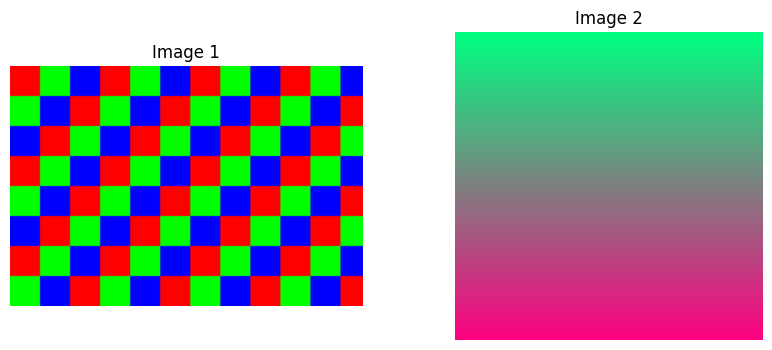

In [2]:
# Image 1: 128x256 RGB checkerboard
h1_img, w1_img = 128, 188
img1 = np.zeros((h1_img, w1_img, 3), dtype=np.uint8)
for i in range(0, h1_img, 16):
    for j in range(0, w1_img, 16):
        color = [(i // 16 + j // 16) % 3 == k for k in range(3)]
        img1[i:i+16, j:j+16] = [255 if c else 0 for c in color]

# Image 2: 128x128 gradient
h2_img, w2_img = 128, 128
img2 = np.zeros((h2_img, w2_img, 3), dtype=np.uint8)
for i in range(h2_img):
    img2[i, :] = [int(255 * i / h2_img), int(255 * (1 - i / h2_img)), 128]

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].imshow(img1)
axes[0].set_title('Image 1')
axes[0].axis('off')
axes[1].imshow(img2)
axes[1].set_title('Image 2')
axes[1].axis('off')
plt.show()

## 2. Create synthetic attention tensor

Shape: `(H1, W1, H2, W2)` — each spatial position in image 1 attends to each spatial position in image 2.

A **structured synthetic pattern** with a strong diagonal positive band and an anti‑diagonal negative band plus random noise.

In [3]:
H1, W1 = 4, 7    # token grid for image 1
H2, W2 = 7, 3      # token grid for image 2

attention = np.random.randn(H1, W1, H2, W2) * 0.3

# Positive diagonal pattern (red lines)
for i1 in range(H1):
    for j1 in range(W1):
        j2 = min(j1 // 2, W2 - 1)
        i2 = min(i1, H2 - 1)
        attention[i1, j1, i2, j2] += np.random.uniform(2.0, 5.0)

# Negative anti‑diagonal pattern (blue lines)
for i1 in range(H1):
    for j1 in range(W1):
        j2 = max(0, W2 - 1 - j1 // 2)
        i2 = H2 - 1 - min(i1, H2 - 1)
        attention[i1, j1, i2, j2] -= np.random.uniform(1.5, 4.0)

print(f'Attention tensor shape: {attention.shape}')
print(f'Value range: [{attention.min():.2f}, {attention.max():.2f}]')

Attention tensor shape: (4, 7, 7, 3)
Value range: [-3.86, 5.44]


## 3. Interactive visualisation

The figure shows:
- Two images at **native aspect ratio**, separated by a pixel gap
- A **black dashed grid** (toggle with the checkbox) showing attention‑token boundaries
- Click on any grid cell → the debug textbox prints the image label and grid coordinates

Controls:
- **Threshold slider** — will filter weak connections once lines are implemented
- **Show Grid checkbox** — toggles the black dashed grid overlay
- **Reset button** — placeholder

In [4]:
import bokeh
w = attention_lol(
    attention,
    img1,
    img2,
    threshold=0.2,
    gap_px=40,
    title="Attention Relevance Demo",
    frame_height=300,
)
w

a:\Adam\Projekty\zennit-crp\attention_viz_human.py:602: UserWarning: found multiple competing values for 'toolbar.logo' property; using the latest value
  plots = gridplot([[fig], [fig_heat]],


Column(id='p1189', ...)

## 4. Minimal example (copy‑paste ready)

If your attention tensor and images are ready, this is all you need:

In [5]:
import numpy as np
from attention_viz_human import attention_lol

# Inputs: random uint8 images + random attention tensor (H1, W1, H2, W2).
attention = np.random.randn(6, 6, 8, 8).astype(np.float32)
img1 = np.random.randint(0, 255, (96, 96, 3), dtype=np.uint8)
img2 = np.random.randint(0, 255, (96, 128, 3), dtype=np.uint8)

# Full feature demo. All kwargs shown; defaults in parentheses.
attention_lol(
    attention, img1, img2,
    threshold=0.2,          # initial |tanh(att)| threshold for line visibility
    gap_px=40,              # data-unit gap between the two images
    title="Attention Demo",
    frame_height=500,       # main figure height in px (before scale)
    curve_bend=0.18,        # how much bezier curves bend (0 = straight)
    max_lines=20000,        # cap on number of rendered curves (top-K by |att|)
    heatmap_height=100,     # heatmap strip height in px (before scale)
    scale=0.6,              # global size multiplier — shrink for small displays
)

# Interactions:
#   - Tap a cell to toggle its selection (multi-select supported).
#     Heatmap under the OTHER image re-aggregates over selected cells.
#   - Threshold slider: coarse update while dragging, exact on release.
#   - mean/max radio: switch aggregation method for heatmaps.
#   - positive/negative checkboxes: toggle line color groups.
#   - Show grid checkbox: overlay dashed grid lines.
#   - Clear selection: reset both image selections.


Column(id='p1410', ...)